# 3. Simulating many cooling rounds

**This is the main notebook.** Every thermal cycle re-traps the interface charge
from scratch, so each cooldown of the same physical device hands you a *fresh
draw* from the disorder distribution — new `d`, new `tcs`, new detuning.

Here we draw thousands of them in a second, from either generative model, and ask
what that does to a device.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # so `import chargetwin` works from notebooks/

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import chargetwin as ct

## Choose your generator

Three routes, all giving a model with the same `.sample()` / `.cooldowns()` API:

1. **Load a precomputed fit** (fastest, no raw data needed).
2. **Refit from the raw ensemble** (if you changed the parameter set).
3. **Swap the dataset** to `rho5e9` for the lower charge density.

In [2]:
PARAMS = ct.FIG5_PARAMETERS
DATASET = "rho1e10"
N_ROUNDS = 2000
SEED = 42

MODELS = ct.data.DATA_ROOT / "models"

# --- route 1: precomputed -----------------------------------------------
gauss = ct.DisorderModel.load(MODELS / f"{DATASET}_gaussian.npz")
pca = ct.DisorderModel.load(MODELS / f"{DATASET}_pca3.npz")

# --- route 2: refit from raw (uncomment to use a different parameter set)
# raw = ct.load_dataset(DATASET, PARAMS)
# gauss = ct.GaussianModel.fit(raw)
# pca = ct.PCAModel.fit(raw, n_components=3)

print("parameters:", gauss.parameters)

parameters: ['d', 'tcs', 'Lxavg', 'dLx', 'Favg', 'dF', 'eps']


## Draw the cooldowns

`cooldowns(n)` returns one row per thermal cycle, tagged with a `round` index.

In [3]:
rounds_cov = gauss.cooldowns(N_ROUNDS, seed=SEED)
rounds_pca = pca.cooldowns(N_ROUNDS, seed=SEED)

rounds_cov.head()

,round,d,tcs,Lxavg,dLx,Favg,dF,eps
0,0,89.963136,102.763028,23.161716,-1.121696,5.162666,0.013257,1.125183
1,1,93.344391,70.185037,23.977492,-0.121703,5.172927,0.005365,-1.486857
2,2,88.335028,111.165243,24.407001,0.345496,5.167449,-0.001133,0.922490
3,3,93.730870,50.804534,23.231250,0.517507,5.183769,-0.001916,-0.429595
4,4,85.774935,107.831336,23.826120,-0.679049,5.164289,0.019624,3.259767


## What a device looks like across cooldowns

The tunnel coupling is the parameter that hurts: it swings across a wide range
from one cooldown to the next, and it is the one you most need inside a target
window.

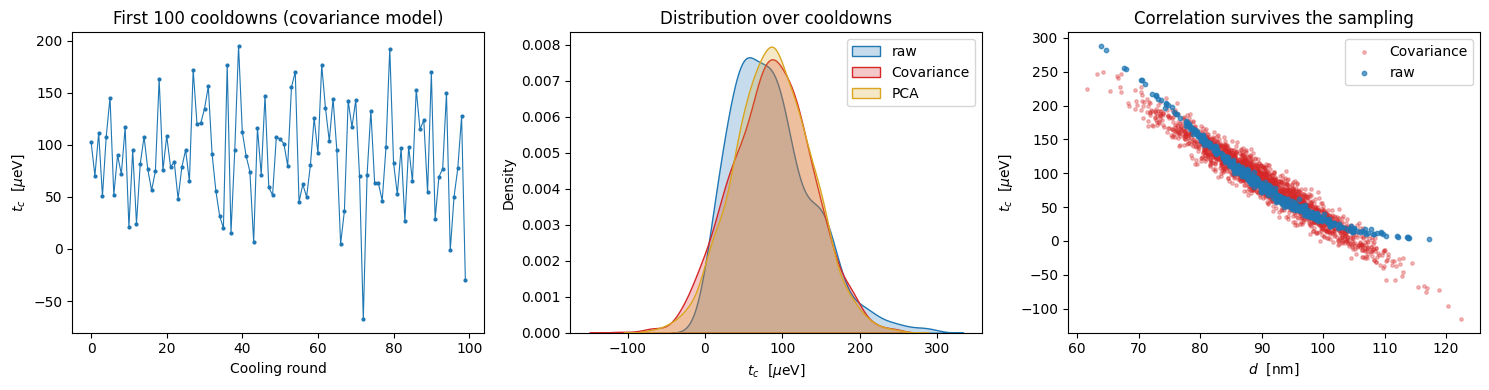

In [4]:
raw = ct.load_dataset(DATASET, PARAMS)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(rounds_cov["round"][:100], rounds_cov["tcs"][:100], ".-", lw=0.8, ms=4)
axes[0].set_xlabel("Cooling round")
axes[0].set_ylabel(r"$t_c$  [$\mu$eV]")
axes[0].set_title("First 100 cooldowns (covariance model)")

for label, df, c in [("raw", raw, "tab:blue"), ("Covariance", rounds_cov, "tab:red"), ("PCA", rounds_pca, "goldenrod")]:
    sns.kdeplot(df["tcs"], ax=axes[1], label=label, color=c, fill=True, alpha=0.25)
axes[1].set_xlabel(r"$t_c$  [$\mu$eV]")
axes[1].legend()
axes[1].set_title("Distribution over cooldowns")

axes[2].scatter(rounds_cov["d"], rounds_cov["tcs"], s=6, alpha=0.3, c="tab:red", label="Covariance")
axes[2].scatter(raw["d"], raw["tcs"], s=10, alpha=0.7, c="tab:blue", label="raw")
axes[2].set_xlabel(r"$d$  [nm]")
axes[2].set_ylabel(r"$t_c$  [$\mu$eV]")
axes[2].legend()
axes[2].set_title("Correlation survives the sampling")

fig.tight_layout()

## Yield: what fraction of cooldowns land in spec?

Define an operating window on the parameters you care about, then just count.
This is the payoff — the model turns "how bad is charge disorder?" into a number
you can compute for any spec, without running COMSOL again.

In [5]:
SPEC = {
    "tcs": (20.0, 150.0),    # tunnel coupling, ueV
    "eps": (-2.0, 2.0),      # detuning, meV
    "d": (75.0, 110.0),      # inter-dot distance, nm
}


def in_spec(df, spec=SPEC):
    ok = pd.Series(True, index=df.index)
    for p, (lo, hi) in spec.items():
        ok &= df[p].between(lo, hi)
    return ok


yields = pd.DataFrame(
    [
        {"source": name, "yield": in_spec(df).mean()}
        for name, df in [("raw (COMSOL)", raw), ("Covariance (A)", rounds_cov), ("PCA (B)", rounds_pca)]
    ]
).set_index("source")

yields.style.format("{:.1%}")

,yield
source,
raw (COMSOL),64.6%
Covariance (A),62.6%
PCA (B),70.5%


### Yield vs. how tight the spec is

Sweep one bound and watch the yield fall off. With 2000 synthetic cooldowns this
curve is smooth; with the 449 raw realizations it would be noisy — that is the
practical reason to generate rather than resample.

Text(0.5, 1.0, 'Yield vs. spec width')

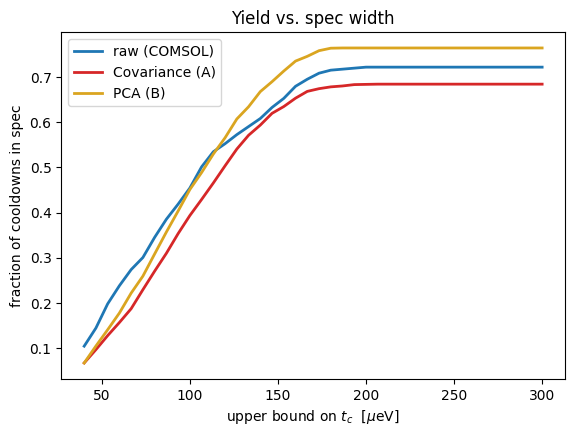

In [6]:
tc_max = np.linspace(40, 300, 40)
curves = {}
for name, df in [("raw (COMSOL)", raw), ("Covariance (A)", rounds_cov), ("PCA (B)", rounds_pca)]:
    curves[name] = [in_spec(df, {**SPEC, "tcs": (20.0, hi)}).mean() for hi in tc_max]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for (name, y), c in zip(curves.items(), ["tab:blue", "tab:red", "goldenrod"]):
    ax.plot(tc_max, y, label=name, color=c, lw=2)
ax.set_xlabel(r"upper bound on $t_c$  [$\mu$eV]")
ax.set_ylabel("fraction of cooldowns in spec")
ax.legend()
ax.set_title("Yield vs. spec width")

## Many devices x many cooldowns

Nothing in the model distinguishes "a different device" from "a different
cooldown" — both are fresh draws. So an experiment with `n_devices` devices each
cooled `n_rounds` times is just a reshape.

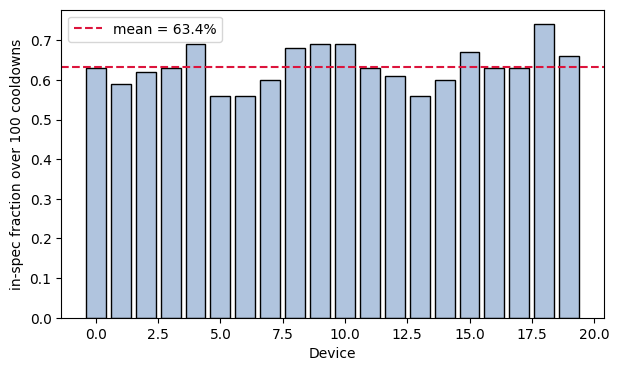

In [7]:
N_DEVICES, N_PER_DEVICE = 20, 100

batch = gauss.sample(N_DEVICES * N_PER_DEVICE, seed=7)
batch["device"] = np.repeat(np.arange(N_DEVICES), N_PER_DEVICE)
batch["round"] = np.tile(np.arange(N_PER_DEVICE), N_DEVICES)

per_device_yield = batch.groupby("device").apply(lambda g: in_spec(g).mean(), include_groups=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(per_device_yield.index, per_device_yield.values, color="lightsteelblue", edgecolor="k")
ax.axhline(per_device_yield.mean(), ls="--", c="crimson", label=f"mean = {per_device_yield.mean():.1%}")
ax.set_xlabel("Device")
ax.set_ylabel(f"in-spec fraction over {N_PER_DEVICE} cooldowns")
ax.legend()

## Export

Hand the realizations to whatever comes next — a Schrödinger solver, a tuning
algorithm, an ML training loop.

In [8]:
out = ct.data.DATA_ROOT / "generated"
out.mkdir(exist_ok=True)
rounds_cov.to_csv(out / f"{DATASET}_cooldowns_covariance.csv", index=False)
rounds_pca.to_csv(out / f"{DATASET}_cooldowns_pca3.csv", index=False)
print(f"wrote {N_ROUNDS} cooldowns x 2 models to {out}")

wrote 2000 cooldowns x 2 models to /Users/krzywdaja/openspin-repos/ChargeTwin/data/generated
